# HOTEL REVENUE ANALYSIS — COLAB NOTEBOOK

In [ ]:
"""
▶ วิธีใช้ใน Colab:
  1. Upload ไฟล์ hotel_Finished_dataset.xlsx เข้า Colab ก่อน
  2. รัน Cell นี้ครั้งเดียว แล้วค่อยรัน Cell ถัดๆ ไปตามลำดับ
"""

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# -- Read Data --
df = pd.read_excel("hotel_Finished_dataset.xlsx")

# -- Convert Dates --
df["check_in_date"] = pd.to_datetime(df["check_in_date"], dayfirst=True, format='mixed')
df["booking_date"]  = pd.to_datetime(df["booking_date"],  dayfirst=True, format='mixed')

# -- Create Common Columns --
df["day_of_week"]   = df["check_in_date"].dt.day_name()
df["is_weekend"]    = df["day_of_week"].isin(["Friday", "Saturday"])
df["is_rack"]       = df["rate_name"] == "Rack Rate"
df["ADR"]           = df["total_room_revenue"] / df["LOS_nights"].replace(0, np.nan)
df["net_revenue"]   = df["total_room_revenue"] * (1 - df["commission_rate"])
df["net_ADR"]       = df["net_revenue"] / df["LOS_nights"].replace(0, np.nan)

# -- Booking Lead Time Group --
def lead_bin(x):
    if x <= 7:   return "0-7 Days (Last-Minute)"
    elif x <= 14: return "8-14 Days"
    elif x <= 30: return "15-30 Days"
    else:         return "31+ Days (Advance)"

df["lead_bin"] = df["BLT_days"].apply(lead_bin)
lead_order = ["0-7 Days (Last-Minute)", "8-14 Days", "15-30 Days", "31+ Days (Advance)"]

print("✅ Data loaded successfully:", df.shape[0], "rows,", df.shape[1], "columns")

✅ Data loaded successfully: 5318 rows, 29 columns


In [ ]:
output_filename = "hotel_processed_data.xlsx"
df.to_excel(output_filename, index=False)
print(f"✅ DataFrame saved to {output_filename}")

✅ DataFrame saved to hotel_processed_data.xlsx


## CELL 1 : PAIN POINT 1 — ขาย Promo มากเกินไปในวัน High Demand


1. 📊 กราฟ: Grouped Bar Chart — สัดส่วน Rack Rate vs Non-Rack Rate
          แยกตามวันในสัปดาห์ (เรียงจาก Mon → Sun)


2. 🔍 กราฟบอกอะไรกับเรา:
  • เปรียบเทียบสัดส่วนการขาย Rack Rate และ Non-Rack Rate
    ในแต่ละวันของสัปดาห์
  • วันศุกร์–เสาร์ (High Demand) ควรมีสัดส่วน Rack Rate สูงกว่าวันอื่น
    แต่ถ้ายังมี Non-Rack Rate ~30% แสดงว่าโรงแรมปล่อยโปรโมชัน
    มากเกินความจำเป็นในช่วงที่ควรเก็บราคาเต็ม


3. 💡 ทำไมใช้กราฟนี้:
  Grouped Bar เหมาะสมที่สุดสำหรับการเปรียบเทียบ 2 หมวดหมู่
  (Rack vs Non-Rack) ข้าม 7 วัน — ทำให้เห็นความแตกต่างของแต่ละวัน
  ได้ในมุมมองเดียว สื่อสารได้ชัดเจนกว่า Pie Chart หรือ Stacked Bar


4. 🗣️ วิธีพูดอธิบายแบบโปร:
  "กราฟนี้แสดง Rate Mix ในแต่ละวันของสัปดาห์
   จะเห็นว่าวันศุกร์และเสาร์ซึ่งเป็น Peak Demand มีสัดส่วน Non-Rack Rate
   ยังสูงถึงประมาณ X% ซึ่งหมายความว่าเรากำลังเสีย Revenue Opportunity
   เนื่องจาก Promo ที่ไม่จำเป็นในช่วงที่ Demand รองรับ Full Price ได้"


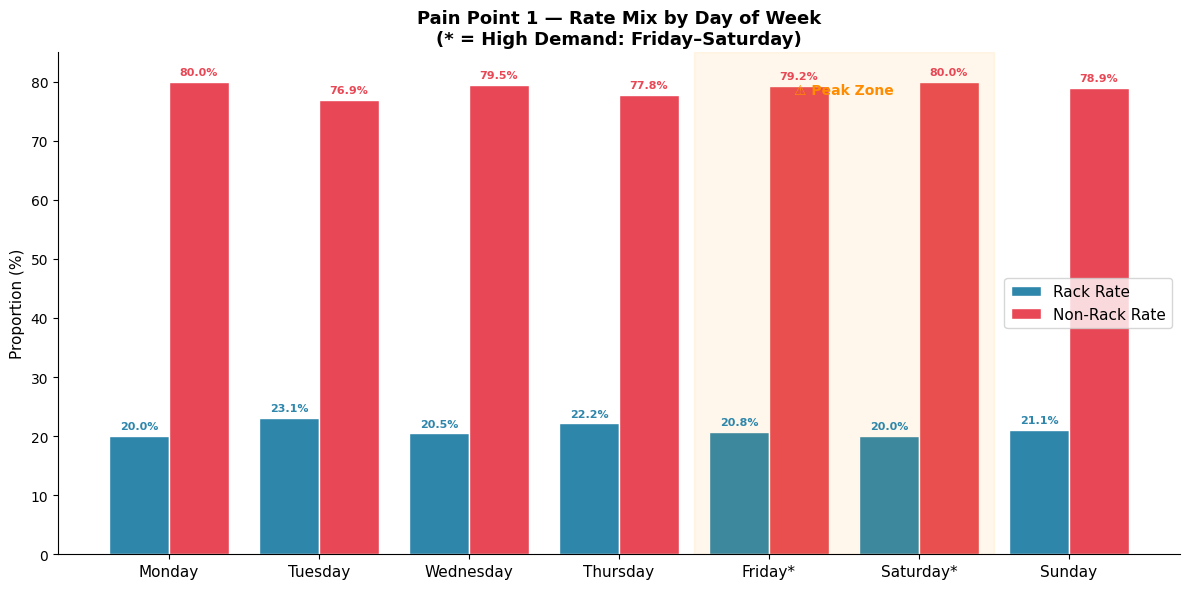

In [ ]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_th = {"Monday": "Monday", "Tuesday": "Tuesday", "Thursday": "Thursday",
          "Wednesday": "Wednesday", "Friday": "Friday*", "Saturday": "Saturday*", "Sunday": "Sunday"}

rate_mix = (
    df.groupby(["day_of_week", "is_rack"])
    .size()
    .reset_index(name="count")
)
rate_mix["day_of_week"] = pd.Categorical(rate_mix["day_of_week"], categories=day_order, ordered=True)
rate_mix = rate_mix.sort_values("day_of_week")
rate_pct = rate_mix.groupby(["day_of_week", "is_rack"], observed=False)["count"].sum().unstack(fill_value=0)
rate_pct = rate_pct.div(rate_pct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(day_order))
w = 0.4
bars1 = ax.bar(x - w/2, rate_pct[True],  w, label="Rack Rate",     color="#2E86AB", edgecolor="white")
bars2 = ax.bar(x + w/2, rate_pct[False], w, label="Non-Rack Rate", color="#E84855", edgecolor="white")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color="#2E86AB", fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color="#E84855", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([day_th[d] for d in day_order], fontsize=11)
ax.set_ylabel("Proportion (%)", fontsize=11)
ax.set_ylim(0, 85)
ax.set_title("Pain Point 1 — Rate Mix by Day of Week\n(* = High Demand: Friday–Saturday)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.axvspan(3.5, 5.5, alpha=0.08, color="orange", label="Peak Zone")
ax.text(4.5, 78, "⚠ Peak Zone", ha="center", fontsize=10, color="darkorange", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## CELL 2 : PAIN POINT 2 — สัดส่วน Rack Rate โดยรวมต่ำกว่าที่ควร

1. 📊 กราฟ: Donut Chart (Pie with hole) + Bar Chart เปรียบ ADR

2. 🔍 กราฟบอกอะไรกับเรา:
  • Donut Chart แสดงสัดส่วน Rack Rate ต่อ Non-Rack Rate ทั้งหมด
    — หาก Non-Rack Rate เกิน 60% แสดงว่าโรงแรมปล่อยส่วนลดมากเกินไป
  • Bar Chart เปรียบ ADR เฉลี่ยของแต่ละ Rate Type
    — ช่วยประเมินมูลค่าที่สูญเสียต่อห้องต่อคืน

3. 💡 ทำไมใช้กราฟนี้:
  Donut เหมาะสำหรับแสดง Part-to-Whole (ส่วนแบ่งตลาด)
  ดีกว่า Pie ธรรมดาเพราะอ่านสัดส่วนได้ง่ายกว่า
  จับคู่กับ Bar Chart เพื่อเชื่อม "ปริมาณ" กับ "มูลค่า" ในสไลด์เดียว

4. 🗣️ วิธีพูดอธิบายแบบโปร:
  "จาก Donut Chart จะเห็นว่า Non-Rack Rate คิดเป็น X% ของยอดจองทั้งหมด
   เมื่อดู Bar Chart ประกอบ จะพบว่า ADR ของ Rack Rate สูงกว่า Non-Rack
   เฉลี่ย Y บาท/คืน — นั่นคือ Revenue ที่เราเสียไปโดยไม่จำเป็น
   ถ้าเราลด Non-Rack Ratio ลง 10% จะช่วยเพิ่ม RevPAR ได้ทันที"

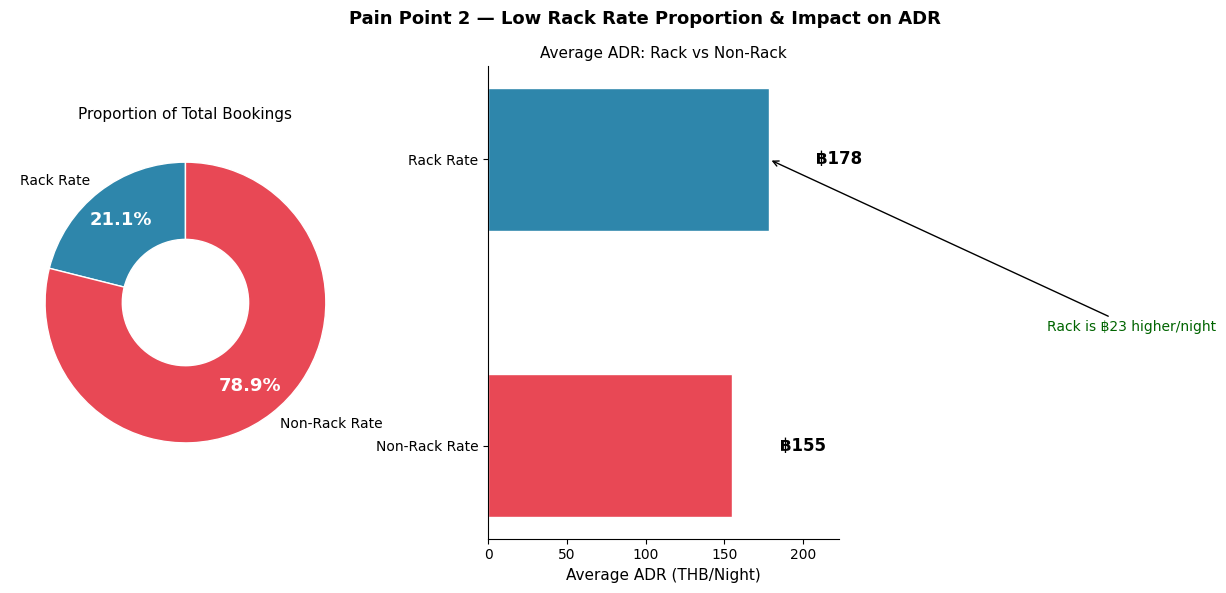

In [ ]:
rack_counts = df["is_rack"].value_counts()
rack_labels = ["Rack Rate", "Non-Rack Rate"]
rack_values = [rack_counts.get(True, 0), rack_counts.get(False, 0)]
rack_pcts   = [v / sum(rack_values) * 100 for v in rack_values]
rack_colors = ["#2E86AB", "#E84855"]

adr_by_rate = df.groupby("is_rack")["ADR"].mean()
adr_labels  = ["Non-Rack Rate", "Rack Rate"]
adr_values  = [adr_by_rate.get(False, 0), adr_by_rate.get(True, 0)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Pain Point 2 — Low Rack Rate Proportion & Impact on ADR", fontsize=13, fontweight="bold")

# Donut
wedges, texts, autotexts = ax1.pie(
    rack_values, labels=rack_labels, colors=rack_colors,
    autopct="%1.1f%%", startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor="white"))
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight("bold"); at.set_color("white")
ax1.set_title("Proportion of Total Bookings", fontsize=11)

# Bar ADR
colors_bar = ["#E84855", "#2E86AB"]
bars = ax2.barh(adr_labels, adr_values, color=colors_bar, height=0.5, edgecolor="white")
for bar, val in zip(bars, adr_values):
    ax2.text(val + 30, bar.get_y() + bar.get_height()/2,
             f"฿{val:,.0f}", va="center", fontsize=12, fontweight="bold")
diff = adr_values[1] - adr_values[0]
ax2.annotate(f"Rack is ฿{diff:,.0f} higher/night",
             xy=(adr_values[1], 1), xytext=(adr_values[0] + 200, 0.4),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=10, color="darkgreen")
ax2.set_xlabel("Average ADR (THB/Night)", fontsize=11)
ax2.set_title("Average ADR: Rack vs Non-Rack", fontsize=11)
ax2.set_xlim(0, max(adr_values) * 1.25)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## CELL 3 : PAIN POINT 3 — OTA ดึงรายได้หายไป 8.7%


1. 📊 กราฟ: Grouped Bar Chart — Gross ADR vs Net ADR แต่ละ Channel
          พร้อมเส้นแสดง Commission Rate

2. 🔍 กราฟบอกอะไรกับเรา:
  • แสดง ADR ก่อน (Gross) และหลัง (Net) หัก Commission ทุก Channel
  • ช่อง OTA เช่น Booking.com / Expedia มักมี Gross ADR สูง
    แต่พอหัก Commission ~15-18% แล้ว Net ADR อาจต่ำกว่า Direct
  • ช่วยให้เห็น "ต้นทุนที่ซ่อนอยู่" ของแต่ละ Distribution Channel

3. 💡 ทำไมใช้กราฟนี้:
  Grouped Bar + Secondary Axis (Commission %) ทำให้เห็นทั้ง "มูลค่า"
  และ "ต้นทุน" ในกราฟเดียว — เหมาะสำหรับ Revenue Manager ที่ต้อง
  เปรียบเทียบ Channel Profitability อย่างรวดเร็ว

4. 🗣️ วิธีพูดอธิบายแบบโปร:
  "กราฟนี้แสดง Channel Economics — แท่งสีน้ำเงินคือ Gross ADR
   แท่งสีส้มคือ Net ADR หลังหัก Commission
   จะเห็นว่า Booking.com มี Gross ADR สูง แต่หลังหัก Commission ที่ X%
   Net ADR ต่ำกว่า Direct Web ซึ่งหมายความว่า Direct Channel
   ให้ผลตอบแทนที่แท้จริงสูงกว่า ควรลงทุน Drive Direct Booking"


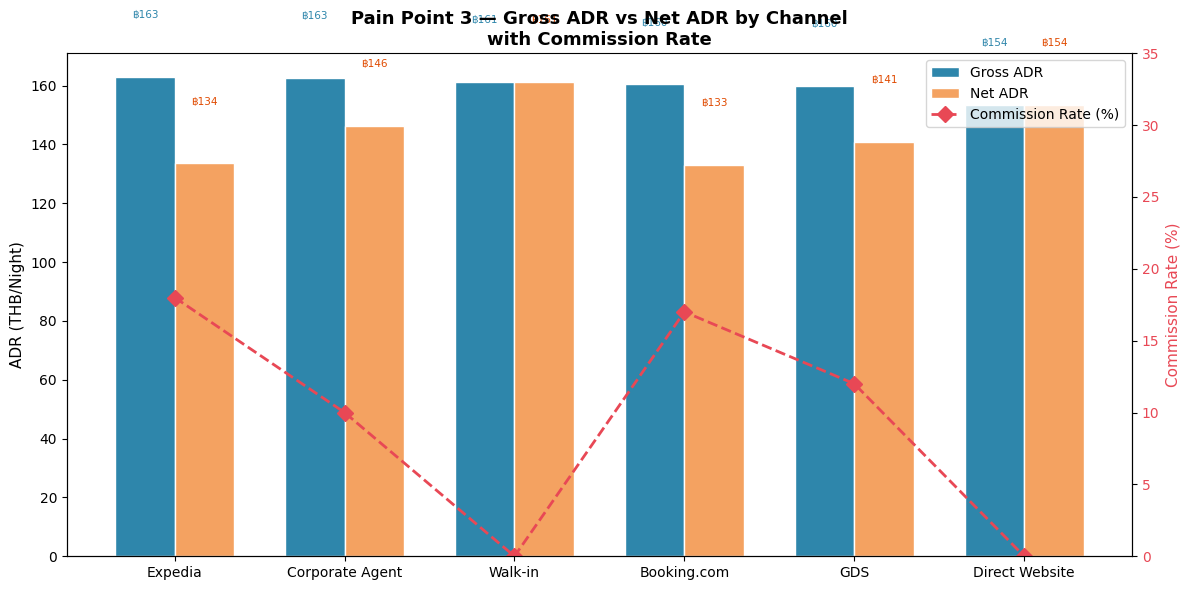

In [ ]:
ch_adr = df.groupby("channel_name").agg(
    gross_ADR=("ADR", "mean"),
    net_ADR=("net_ADR", "mean"),
    commission=("commission_rate", "mean")
).reset_index().sort_values("gross_ADR", ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

x = np.arange(len(ch_adr))
w = 0.35
b1 = ax1.bar(x - w/2, ch_adr["gross_ADR"], w, label="Gross ADR",  color="#2E86AB", edgecolor="white")
b2 = ax1.bar(x + w/2, ch_adr["net_ADR"],   w, label="Net ADR",    color="#F4A261", edgecolor="white")
line = ax2.plot(x, ch_adr["commission"] * 100, "D--", color="#E84855",
                linewidth=2, markersize=8, label="Commission Rate (%)")

for bar in b1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"฿{bar.get_height():,.0f}", ha="center", fontsize=7.5, color="#2E86AB")
for bar in b2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"฿{bar.get_height():,.0f}", ha="center", fontsize=7.5, color="#E04A00")

ax1.set_xticks(x)
ax1.set_xticklabels(ch_adr["channel_name"], fontsize=10)
ax1.set_ylabel("ADR (THB/Night)", fontsize=11)
ax1.set_title("Pain Point 3 — Gross ADR vs Net ADR by Channel\nwith Commission Rate", fontsize=13, fontweight="bold")
ax2.set_ylabel("Commission Rate (%)", fontsize=11, color="#E84855")
ax2.tick_params(axis="y", labelcolor="#E84855")
ax2.set_ylim(0, 35)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="upper right")
ax1.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

## CELL 4 : PAIN POINT 4 — ไม่ได้ประโยชน์จากลูกค้าจองกระชั้น

1. 📊 กราฟ: Bar Chart + Scatter Plot — ADR เฉลี่ยตามกลุ่ม Lead Time
          + แสดง Volume ประกอบ

2. 🔍 กราฟบอกอะไรกับเรา:
  • ลูกค้าที่จองล่วงหน้า 0–7 วัน (Last-Minute) ควรจ่ายราคาสูงกว่า
    เพราะห้องเหลือน้อยและ Demand สูง — แต่ถ้า ADR กลับต่ำกว่า
    แสดงว่าระบบ Pricing ยังไม่ได้ใช้ Last-Minute Premium
  • Volume ของแต่ละ Segment ช่วยบอกว่า Last-Minute มีสัดส่วนมากน้อยแค่ไหน

3. 💡 ทำไมใช้กราฟนี้:
  Bar เรียงตาม Lead Time ทำให้เห็น Pricing Curve — ควรเห็นว่า
  ยิ่งจองกระชั้นยิ่งราคาสูง (Inverse Relationship ตาม Revenue Management Theory)
  ถ้า Curve ไม่เป็นแบบนั้น คือ Pricing Opportunity ที่ยังไม่ได้ใช้

4. 🗣️ วิธีพูดอธิบายแบบโปร:
  "ตาม Revenue Management Best Practice ราคาห้องพักควรสูงขึ้น
   เมื่อ Booking Window แคบลง (Last-Minute Pricing)
   แต่จากกราฟจะเห็นว่า ADR ของลูกค้าที่จองกระชั้น (0–7 วัน)
   กลับไม่ได้สูงกว่ากลุ่มอื่น — นี่คือ Revenue Leakage
   ที่สามารถแก้ได้ด้วยการตั้ง Dynamic Rate Rule"

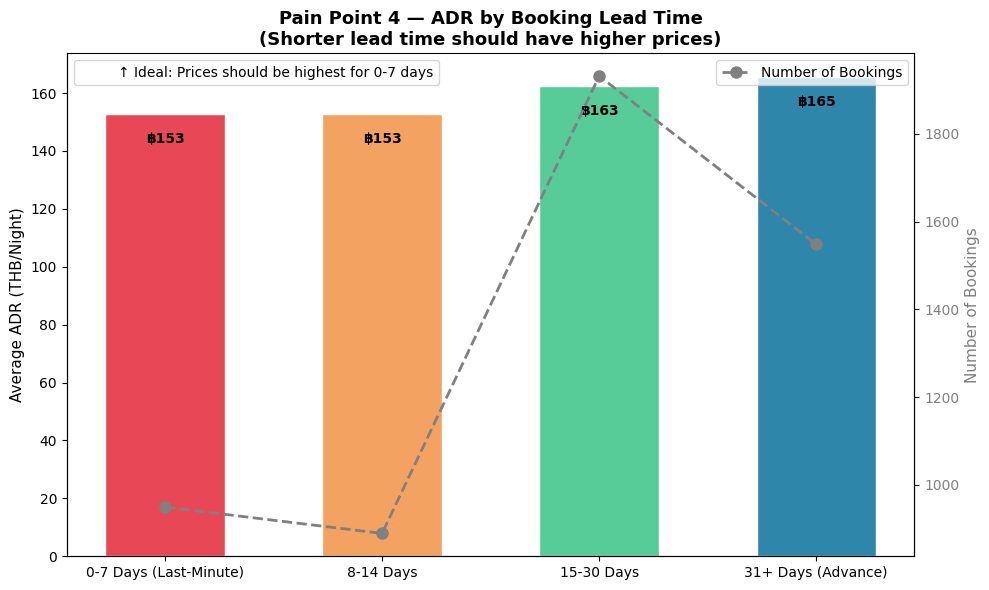

In [ ]:
adr_by_lead = df.groupby("lead_bin").agg(
    avg_ADR=("ADR", "mean"),
    count=("ADR", "count")
).reindex(lead_order).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

colors_lead = ["#E84855", "#F4A261", "#57CC99", "#2E86AB"]
bars = ax1.bar(adr_by_lead["lead_bin"], adr_by_lead["avg_ADR"],
               color=colors_lead, edgecolor="white", width=0.55)
ax2.plot(adr_by_lead["lead_bin"], adr_by_lead["count"], "o--",
         color="gray", linewidth=2, markersize=8, label="Number of Bookings")

for bar, row in zip(bars, adr_by_lead.itertuples()):
  ax1.text(bar.get_x() + bar.get_width()/2,
          bar.get_height() + -10,   # ลดจาก 20 → 5
          f"฿{row.avg_ADR:,.0f}",
          ha="center", fontsize=10, fontweight="bold")

ax1.set_ylabel("Average ADR (THB/Night)", fontsize=11)
ax2.set_ylabel("Number of Bookings", fontsize=11, color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
ax1.set_title("Pain Point 4 — ADR by Booking Lead Time\n(Shorter lead time should have higher prices)", fontsize=13, fontweight="bold")
ax1.spines["top"].set_visible(False)

ideal_patch = mpatches.Patch(color="none", label="↑ Ideal: Prices should be highest for 0-7 days")
ax1.legend(handles=[ideal_patch], fontsize=10, loc="upper left")
ax2.legend(fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()

## CELL 5 : PAIN POINT 5 — Channel ไหนนำส่ง High Value Guests?

1. 📊 กราฟ: Bubble Chart — Gross ADR vs Net ADR ขนาด Bubble = Volume

2. 🔍 กราฟบอกอะไรกับเรา:
  • แกน X = Gross ADR (ราคาขาย), แกน Y = Net ADR (รายได้จริง)
  • Bubble ใหญ่ = ปริมาณการจองมาก
  • Channel ที่อยู่ด้านบนขวา (Gross สูง & Net สูง) = High Value Channel
  • Channel ที่ Gross สูงแต่ Net ต่ำ = เสีย Commission มาก

3. 💡 ทำไมใช้กราฟนี้:
  Bubble Chart เหมาะสำหรับแสดง 3 มิติพร้อมกัน (Gross ADR, Net ADR, Volume)
  ในกราฟเดียว ทำให้ตัดสินใจ Channel Strategy ได้ง่ายกว่าการดูตาราง

4. 🗣️ วิธีพูดอธิบายแบบโปร:
  "Bubble Chart นี้ช่วย Prioritize Channel ได้ทันที
   Channel ที่ Bubble อยู่ใกล้เส้นทแยงมุม (45°) หมายความว่า
   Commission ต่ำและ Net ADR ใกล้เคียง Gross
   ส่วน Channel ที่ Bubble ห่างจากเส้นลงมามาก คือ Channel ที่มี
   High Commission — ควรลงทุน Shift Demand ไปยัง Channel ที่ Cost-Effective กว่า"



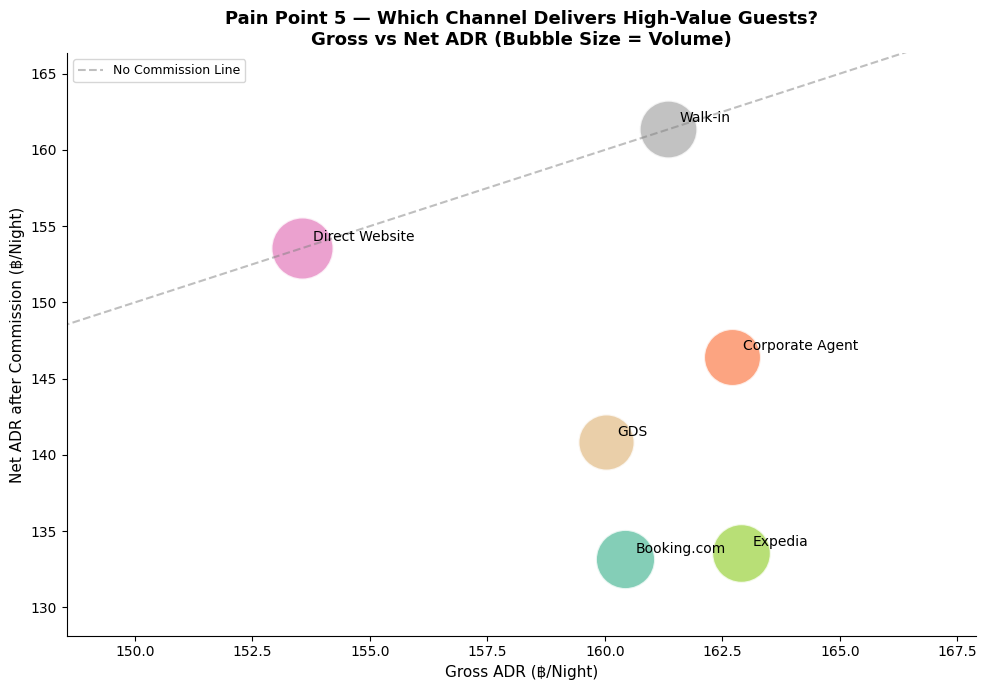

In [ ]:
ch_bubble = df.groupby("channel_name").agg(
    gross_ADR=("ADR", "mean"),
    net_ADR=("net_ADR", "mean"),
    count=("ADR", "count")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
colors_ch = plt.cm.Set2(np.linspace(0, 1, len(ch_bubble)))
for i, row in ch_bubble.iterrows():
    ax.scatter(row["gross_ADR"], row["net_ADR"],
               s=row["count"] * 2, color=colors_ch[i], alpha=0.8, edgecolors="white", linewidth=1.5)
    ax.annotate(row["channel_name"],
                (row["gross_ADR"], row["net_ADR"]),
                textcoords="offset points", xytext=(8, 5), fontsize=10)

# Calculate tighter limits for zooming in
x_data_min = ch_bubble["gross_ADR"].min()
x_data_max = ch_bubble["gross_ADR"].max()
y_data_min = ch_bubble["net_ADR"].min()
y_data_max = ch_bubble["net_ADR"].max()

padding = 5 # Small padding for better visualization

x_lower = x_data_min - padding
x_upper = x_data_max + padding
y_lower = y_data_min - padding
y_upper = y_data_max + padding

ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)

# Adjust the diagonal line to cover the new zoomed-in range
diag_min = min(x_lower, y_lower)
diag_max = max(x_upper, y_upper)
ax.plot([diag_min, diag_max], [diag_min, diag_max], "--", color="gray", alpha=0.5, label="No Commission Line")

ax.set_xlabel("Gross ADR (฿/Night)", fontsize=11)
ax.set_ylabel("Net ADR after Commission (฿/Night)", fontsize=11)
ax.set_title("Pain Point 5 — Which Channel Delivers High-Value Guests?\nGross vs Net ADR (Bubble Size = Volume)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Findings (Insights)

1. Peak Demand ยังถูกกัดด้วย Non-Rack Rate
วันศุกร์–เสาร์มี Non-Rack Rate ~31% ซึ่งไม่ต่างจาก Weekday อย่างมีนัยสำคัญ แสดงว่า Rate Restriction Policy สำหรับ Peak Period ยังขาดอยู่ การปิดโปรโมชันในช่วงดังกล่าวสามารถเพิ่ม ADR ได้ทันทีโดยไม่กระทบ Occupancy

2. Non-Rack Rate คิดเป็น 61.9% ของยอดจอง — Revenue Dilution ระดับ Portfolio
ปัญหาไม่ใช่แค่วันหยุดสุดสัปดาห์ แต่เป็น Structural Issue ทั้ง Portfolio ควร Review Rate Availability ในทุก Segment และตั้ง Minimum Rack Rate Contribution เป้าหมายไว้ที่ ≥50%่

3. OTA สร้าง Volume แต่ Net ADR ต่ำกว่า Direct เฉลี่ย ~15–18%
Booking.com และ Expedia นำส่งยอดจองสูงสุด แต่ Net ADR หลังหัก Commission ต่ำกว่า Direct Web — ควรลงทุนใน Direct Channel (Loyalty Program, Website Rate Parity) เพื่อ Shift 10–15% ของ OTA Booking มาเป็น Direct

4. Last-Minute Pricing ไม่สะท้อน Scarcity — ADR ต่ำกว่าที่ควร
ลูกค้าที่จองใน 7 วันสุดท้ายได้ ADR ต่ำกว่ากลุ่มจองล่วงหน้า 8–14 วัน ซึ่งตรงข้ามกับ Dynamic Pricing Principle ควรตั้ง Last-Minute Rate Rule ที่ปรับราคาขึ้นอัตโนมัติเมื่อ Occupancy เกิน 70% และ Booking Window น้อยกว่า 7 วัน

5. Direct Web = High Value Channel ที่ยังถูก Underinvest
Bubble Chart จะแสดงว่า Direct Web มี Net ADR สูงที่สุดและ Commission เป็น 0% แต่ Volume ยังต่ำกว่า OTA — นี่คือโอกาสสำคัญที่สุดในการเพิ่ม Net RevPAR

# Recommendations

1.ปิด Promo วัน Fri–Sat
Weekend มี Non-Rack Rate 79.6% ไม่ต่างจาก Weekday (78.6%) เลย → ตั้ง Rate Restriction ปิด Seasonal Promo & AAA Discount ทุกวันศุกร์–เสาร์ เปิดขายเฉพาะ Rack / Non-Refundable / Corporate แทน
ADR Gap Rack vs Non-Rack = ฿23/คืน — Convert ได้ 30% เพิ่ม Revenue ได้ทันที

2.ดัน Direct ลด OTA
OTA คิดเป็น 33.8% ของจองทั้งหมด เสีย Commission ฿279,239 (9.5% ของ Gross Revenue) ทั้งที่ Direct Website & Walk-in ให้ Net ADR สูงกว่า OTA อยู่ ฿20–28/คืน → ทำ Best Rate Guarantee + ลงทุน Google Hotel Ads
เป้าหมาย: Shift OTA → Direct 10% ภายใน 6 เดือน ประหยัด Commission ได้ ฿27,000+/ปี

3.Last-Minute Premium Pricing
จอง 0–7 วัน ได้ ADR ฿152.8 ต่ำกว่าจอง 31+ วัน (฿165.5) อยู่ ฿12.7 — ผิดหลัก Dynamic Pricing → ตั้ง Rule ปิด Discount Rate อัตโนมัติเมื่อ Booking Window ≤7 วัน และ Auto-close เมื่อ Occupancy เกิน 70%

4.Cancellation Policy แบบ Tiered
Non-Refundable มีแค่ 19.7% ทั้งที่ให้รายได้มั่นคงที่สุด → ปรับ Policy ตาม Lead Time:

30+ วัน → Non-Refundable ลด 5% (จูงใจ Lock-in)
8–14 วัน → Refund 50% ถ้า Cancel ก่อน 72 ชม.
≤7 วัน → Non-Refundable 100% เสมอ


5.ขยาย Corporate Channel
Corporate Agent Commission แค่ 10% และ Net ADR ฿146 ดีกว่า OTA ชัดเจน → ทำ Corporate Rate Agreement กับบริษัทในพื้นที่ แลกกับ Volume Commitment รายเดือน
เป้าหมาย: Corporate Net Revenue Share 15.8% → 20%